In [1]:
import os
import joblib
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
dataset = pd.read_excel("data/flood_prediction.xlsx")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
dataset.head()

,Temp,Humidity,Cloud Cover,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,avgjune,sub,flood
0,29,70,30,3248.6,73.4,386.2,2122.8,666.1,274.866667,649.9,0
1,28,75,40,3326.6,9.3,275.7,2403.4,638.2,130.300000,256.4,1
2,28,75,42,3271.2,21.7,336.3,2343.0,570.1,186.200000,308.9,0
3,29,71,44,3129.7,26.7,339.4,2398.2,365.3,366.066667,862.5,0
4,31,74,40,2741.6,23.4,378.5,1881.5,458.1,283.400000,586.9,0


In [4]:
print("Dataset Shape:", dataset.shape)

Dataset Shape: (115, 11)


In [5]:
print(dataset.columns.tolist())

['Temp', 'Humidity', 'Cloud Cover', 'ANNUAL', 'Jan-Feb', 'Mar-May', 'Jun-Sep', 'Oct-Dec', 'avgjune', 'sub', 'flood']


In [6]:
dataset.columns = dataset.columns.str.strip()

print(dataset.columns.tolist())

['Temp', 'Humidity', 'Cloud Cover', 'ANNUAL', 'Jan-Feb', 'Mar-May', 'Jun-Sep', 'Oct-Dec', 'avgjune', 'sub', 'flood']


In [7]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 115 entries, 0 to 114
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temp         115 non-null    int64  
 1   Humidity     115 non-null    int64  
 2   Cloud Cover  115 non-null    int64  
 3   ANNUAL       115 non-null    float64
 4   Jan-Feb      115 non-null    float64
 5   Mar-May      115 non-null    float64
 6   Jun-Sep      115 non-null    float64
 7   Oct-Dec      115 non-null    float64
 8   avgjune      115 non-null    float64
 9   sub          115 non-null    float64
 10  flood        115 non-null    int64  
dtypes: float64(7), int64(4)
memory usage: 10.0 KB


In [8]:
dataset.describe()

,Temp,Humidity,Cloud Cover,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,avgjune,sub,flood
count,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000
mean,29.600000,73.852174,36.286957,2925.487826,27.739130,377.253913,2022.840870,497.636522,218.100870,439.801739,0.139130
std,1.122341,2.947623,4.330158,422.112193,22.361032,151.091850,386.254397,129.860643,62.547597,210.438813,0.347597
min,28.000000,70.000000,30.000000,2068.800000,0.300000,89.900000,1104.300000,166.600000,65.600000,34.200000,0.000000
25%,29.000000,71.000000,32.500000,2627.900000,10.250000,276.750000,1768.850000,407.450000,179.666667,295.000000,0.000000
50%,30.000000,74.000000,36.000000,2937.500000,20.500000,342.000000,1948.700000,501.500000,211.033333,430.600000,0.000000
75%,31.000000,76.000000,40.000000,3164.100000,41.600000,442.300000,2242.900000,584.550000,263.833333,577.650000,0.000000
max,31.000000,79.000000,44.000000,4257.800000,98.100000,915.200000,3451.300000,823.300000,366.066667,982.700000,1.000000


In [9]:
print("Missing Values:")
print(dataset.isnull().sum())

Missing Values:
Temp           0
Humidity       0
Cloud Cover    0
ANNUAL         0
Jan-Feb        0
Mar-May        0
Jun-Sep        0
Oct-Dec        0
avgjune        0
sub            0
flood          0
dtype: int64


In [10]:
print("Duplicate Rows:", dataset.duplicated().sum())

Duplicate Rows: 0


In [11]:
print(dataset["flood"].value_counts())

flood
0    99
1    16
Name: count, dtype: int64


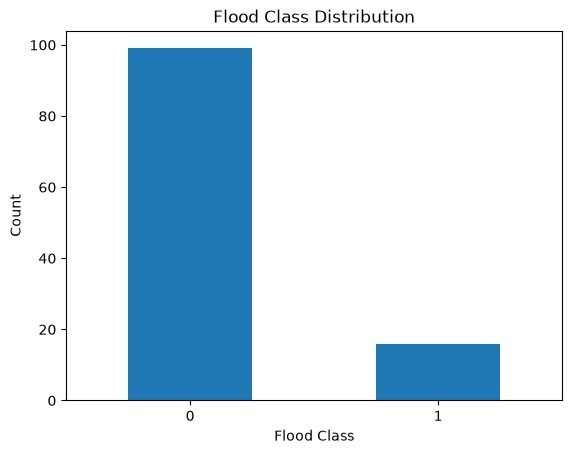

In [12]:
dataset["flood"].value_counts().plot(
    kind="bar",
    title="Flood Class Distribution"
)

plt.xlabel("Flood Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

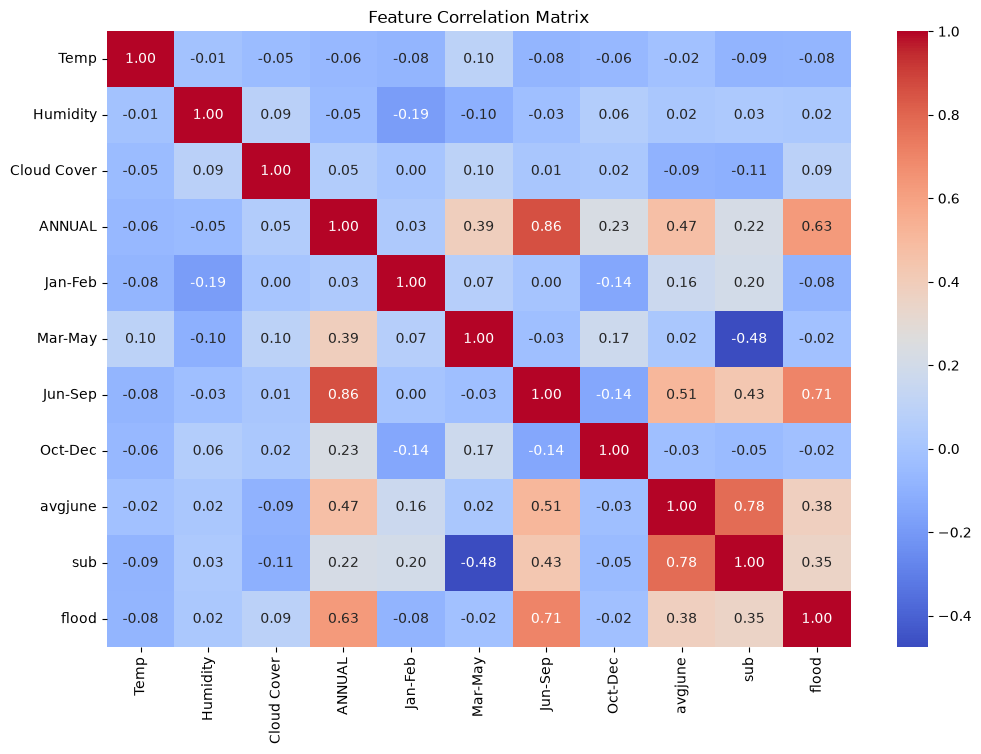

In [13]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    dataset.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Matrix")
plt.show()

In [14]:
X = dataset.drop("flood", axis=1)

y = dataset["flood"]

In [15]:
print("Feature Columns:")
print(X.columns.tolist())

print("\nFeatures Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Columns:
['Temp', 'Humidity', 'Cloud Cover', 'ANNUAL', 'Jan-Feb', 'Mar-May', 'Jun-Sep', 'Oct-Dec', 'avgjune', 'sub']

Features Shape: (115, 10)
Target Shape: (115,)


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [17]:
print("X_train Shape:", X_train.shape)
print("X_test Shape :", X_test.shape)

print("y_train Shape:", y_train.shape)
print("y_test Shape :", y_test.shape)

X_train Shape: (92, 10)
X_test Shape : (23, 10)
y_train Shape: (92,)
y_test Shape : (23,)


In [18]:
print("\nTraining Target Distribution:")
print(y_train.value_counts())

print("\nTesting Target Distribution:")
print(y_test.value_counts())


Training Target Distribution:
flood
0    79
1    13
Name: count, dtype: int64

Testing Target Distribution:
flood
0    20
1     3
Name: count, dtype: int64


In [19]:
logistic_model = LogisticRegression(
    max_iter=5000,
    random_state=42
)

logistic_model.fit(X_train, y_train)

logistic_pred = logistic_model.predict(X_test)

logistic_accuracy = accuracy_score(
    y_test,
    logistic_pred
)

print(
    "Logistic Regression Accuracy:",
    logistic_accuracy
)

Logistic Regression Accuracy: 0.9565217391304348


In [20]:
decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

decision_tree_model.fit(
    X_train,
    y_train
)

decision_tree_pred = decision_tree_model.predict(
    X_test
)

decision_tree_accuracy = accuracy_score(
    y_test,
    decision_tree_pred
)

print(
    "Decision Tree Accuracy:",
    decision_tree_accuracy
)

Decision Tree Accuracy: 0.9565217391304348


In [21]:
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest_model.fit(
    X_train,
    y_train
)

random_forest_pred = random_forest_model.predict(
    X_test
)

random_forest_accuracy = accuracy_score(
    y_test,
    random_forest_pred
)

print(
    "Random Forest Accuracy:",
    random_forest_accuracy
)

Random Forest Accuracy: 0.9565217391304348


In [22]:
xgboost_model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric="logloss"
)

xgboost_model.fit(
    X_train,
    y_train
)

xgboost_pred = xgboost_model.predict(
    X_test
)

xgboost_accuracy = accuracy_score(
    y_test,
    xgboost_pred
)

print(
    "XGBoost Accuracy:",
    xgboost_accuracy
)

XGBoost Accuracy: 0.8695652173913043


In [23]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    
    "Accuracy": [
        logistic_accuracy,
        decision_tree_accuracy,
        random_forest_accuracy,
        xgboost_accuracy
    ]
})

results = results.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

results

,Model,Accuracy
0,Logistic Regression,0.956522
1,Decision Tree,0.956522
2,Random Forest,0.956522
3,XGBoost,0.869565


In [24]:
results_percentage = results.copy()

results_percentage["Accuracy"] = (
    results_percentage["Accuracy"] * 100
).round(2)

results_percentage["Accuracy"] = (
    results_percentage["Accuracy"]
    .astype(str)
    + "%"
)

results_percentage

,Model,Accuracy
0,Logistic Regression,95.65%
1,Decision Tree,95.65%
2,Random Forest,95.65%
3,XGBoost,86.96%


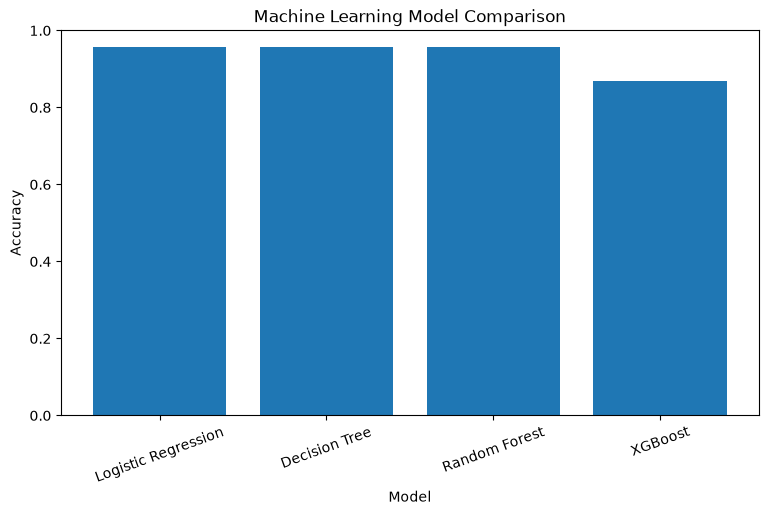

In [25]:
plt.figure(figsize=(9, 5))

plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.title("Machine Learning Model Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.ylim(0, 1)

plt.xticks(rotation=20)

plt.show()

In [26]:
print("Random Forest Accuracy:")
print(
    accuracy_score(
        y_test,
        random_forest_pred
    )
)

Random Forest Accuracy:
0.9565217391304348


In [27]:
rf_confusion_matrix = confusion_matrix(
    y_test,
    random_forest_pred
)

print("Confusion Matrix:")
print(rf_confusion_matrix)

Confusion Matrix:
[[20  0]
 [ 1  2]]


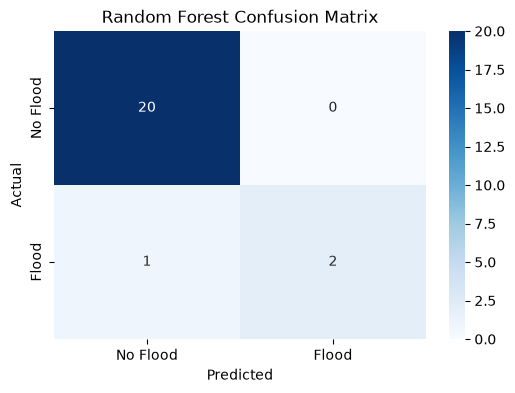

In [28]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    rf_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Flood", "Flood"],
    yticklabels=["No Flood", "Flood"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [29]:
print(
    classification_report(
        y_test,
        random_forest_pred,
        target_names=[
            "No Flood",
            "Flood"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

    No Flood       0.95      1.00      0.98        20
       Flood       1.00      0.67      0.80         3

    accuracy                           0.96        23
   macro avg       0.98      0.83      0.89        23
weighted avg       0.96      0.96      0.95        23



In [30]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
6,Jun-Sep,0.520786
3,ANNUAL,0.235143
9,sub,0.075681
8,avgjune,0.061186
2,Cloud Cover,0.026077
5,Mar-May,0.025531
7,Oct-Dec,0.024455
4,Jan-Feb,0.015674
1,Humidity,0.007934
0,Temp,0.007533


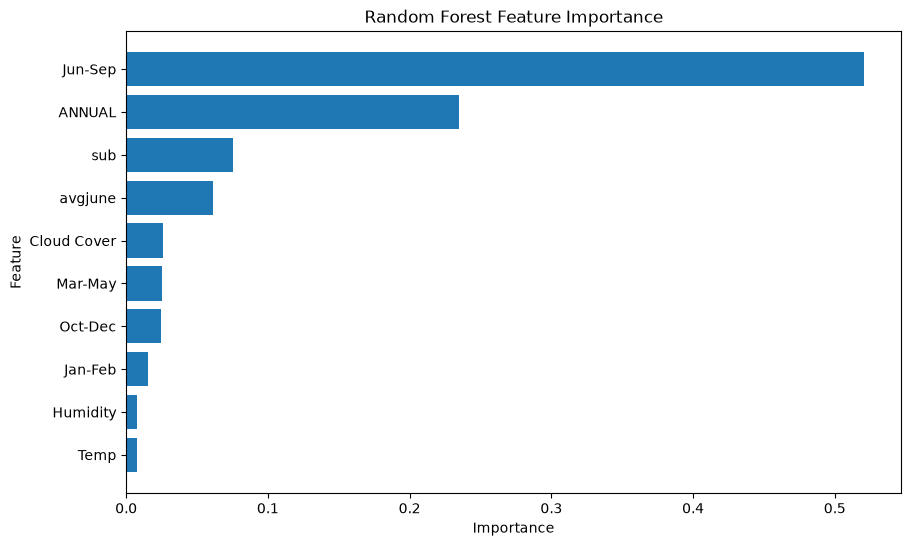

In [31]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [32]:
os.makedirs(
    "models",
    exist_ok=True
)

joblib.dump(
    random_forest_model,
    "models/floods.save"
)

print(
    "Random Forest model saved successfully!"
)

Random Forest model saved successfully!


In [33]:
saved_model = joblib.load(
    "models/floods.save"
)

print(saved_model)

RandomForestClassifier(random_state=42)


In [34]:
saved_model_predictions = saved_model.predict(
    X_test
)

saved_model_accuracy = accuracy_score(
    y_test,
    saved_model_predictions
)

print(
    "Saved Model Accuracy:",
    saved_model_accuracy
)

print(
    "\nSaved Model Confusion Matrix:"
)

print(
    confusion_matrix(
        y_test,
        saved_model_predictions
    )
)

Saved Model Accuracy: 0.9565217391304348

Saved Model Confusion Matrix:
[[20  0]
 [ 1  2]]


In [35]:
print(
    "Original RF Accuracy:",
    random_forest_accuracy
)

print(
    "Saved RF Accuracy:",
    saved_model_accuracy
)

Original RF Accuracy: 0.9565217391304348
Saved RF Accuracy: 0.9565217391304348


In [36]:
all_predictions = saved_model.predict(X)

prediction_check = X.copy()

prediction_check["Actual"] = y.values

prediction_check["Predicted"] = all_predictions

prediction_check.head()

,Temp,Humidity,Cloud Cover,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,avgjune,sub,Actual,Predicted
0,29,70,30,3248.6,73.4,386.2,2122.8,666.1,274.866667,649.9,0,0
1,28,75,40,3326.6,9.3,275.7,2403.4,638.2,130.300000,256.4,1,0
2,28,75,42,3271.2,21.7,336.3,2343.0,570.1,186.200000,308.9,0,0
3,29,71,44,3129.7,26.7,339.4,2398.2,365.3,366.066667,862.5,0,0
4,31,74,40,2741.6,23.4,378.5,1881.5,458.1,283.400000,586.9,0,0


In [37]:
correct_flood_samples = prediction_check[
    (prediction_check["Actual"] == 1) &
    (prediction_check["Predicted"] == 1)
]

print(
    "Number of correctly predicted flood samples:",
    len(correct_flood_samples)
)

correct_flood_samples

Number of correctly predicted flood samples: 15


,Temp,Humidity,Cloud Cover,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,avgjune,sub,Actual,Predicted
6,29,74,40,3671.1,23.7,328.0,2737.8,581.7,256.966667,669.5,1,1
11,28,77,40,3451.3,16.9,351.1,2453.1,630.2,316.066667,730.9,1,1
22,28,70,30,3484.7,25.3,202.3,2928.4,328.6,240.833333,642.5,1,1
23,30,71,41,4226.4,22.2,363.0,3451.3,389.9,337.233333,826.3,1,1
30,30,73,30,3259.6,3.6,277.8,2558.0,420.1,180.566667,410.0,1,1
32,31,75,42,4072.9,10.3,915.2,2581.9,565.5,286.433333,120.5,1,1
45,28,72,42,3565.5,7.3,331.2,2485.7,741.3,306.333333,836.0,1,1
58,29,74,35,3746.0,24.3,504.2,2831.2,386.3,290.933333,525.6,1,1
60,30,72,30,4257.8,45.0,606.0,3229.3,377.6,335.066667,504.7,1,1
67,29,76,33,3392.7,37.8,312.5,2711.4,331.0,232.133333,606.4,1,1


In [38]:
if len(correct_flood_samples) > 0:

    flood_example = correct_flood_samples.iloc[0]

    print("Flood Test Input:")
    print(flood_example)

else:

    print(
        "No correctly predicted flood sample found."
    )

Flood Test Input:
Temp             29.000000
Humidity         74.000000
Cloud Cover      40.000000
ANNUAL         3671.100000
Jan-Feb          23.700000
Mar-May         328.000000
Jun-Sep        2737.800000
Oct-Dec         581.700000
avgjune         256.966667
sub             669.500000
Actual            1.000000
Predicted         1.000000
Name: 6, dtype: float64


In [39]:
if len(correct_flood_samples) > 0:

    flood_input = correct_flood_samples[
        X.columns
    ].iloc[[0]]

    prediction = saved_model.predict(
        flood_input
    )[0]

    probabilities = saved_model.predict_proba(
        flood_input
    )[0]

    print(
        "Prediction:",
        prediction
    )

    print(
        "No Flood Probability:",
        probabilities[0]
    )

    print(
        "Flood Probability:",
        probabilities[1]
    )

Prediction: 1
No Flood Probability: 0.02
Flood Probability: 0.98


In [40]:
if len(correct_flood_samples) > 0:

    flood_input = correct_flood_samples[
        X.columns
    ].iloc[0]

    print(
        "Temperature:",
        flood_input["Temp"]
    )

    print(
        "Humidity:",
        flood_input["Humidity"]
    )

    print(
        "Cloud Cover:",
        flood_input["Cloud Cover"]
    )

    print(
        "Annual Rainfall:",
        flood_input["ANNUAL"]
    )

    print(
        "Jan-Feb Rainfall:",
        flood_input["Jan-Feb"]
    )

    print(
        "Mar-May Rainfall:",
        flood_input["Mar-May"]
    )

    print(
        "Jun-Sep Rainfall:",
        flood_input["Jun-Sep"]
    )

    print(
        "Oct-Dec Rainfall:",
        flood_input["Oct-Dec"]
    )

    print(
        "Average June Rainfall:",
        flood_input["avgjune"]
    )

    print(
        "Sub Rainfall:",
        flood_input["sub"]
    )

Temperature: 29.0
Humidity: 74.0
Cloud Cover: 40.0
Annual Rainfall: 3671.1
Jan-Feb Rainfall: 23.7
Mar-May Rainfall: 328.0
Jun-Sep Rainfall: 2737.8
Oct-Dec Rainfall: 581.7
Average June Rainfall: 256.9666666666666
Sub Rainfall: 669.5
